# Credit Card Default Prediction
## Lightning Talk #2 - Deep EDA, Preprocessing Plan & Modeling Approach

### Refined Problem Statement

Financial institutions face significant losses due to credit card defaults. Traditional credit scoring methods fail to capture complex behavioral patterns in payment history and spending habits. Using 30,000 Taiwan credit card clients with 24 features including 6 months of payment status, bill amounts, and repayment amounts we aim to build a binary classification model that predicts whether a client will default next month.

**Target:** `default payment next month` (0 = no default, 1 = default)

**Why it matters:** Early identification of high risk clients allows banks to intervene proactively  reducing write-offs, adjusting credit limits, and improving portfolio health.


loading imports

In [5]:
import sys, subprocess
subprocess.run([sys.executable, '-m', 'pip', 'install', 'xlrd'], capture_output=True)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10
print('imports done')

imports done


# 1. UNDERSTANDING THE DATA (Data Dictionary)

loading the dataset

In [6]:
df = pd.read_excel('default of credit card clients.xls', header=1)
df.shape

(30000, 25)

In [7]:
df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   ID                          30000 non-null  int64
 1   LIMIT_BAL                   30000 non-null  int64
 2   SEX                         30000 non-null  int64
 3   EDUCATION                   30000 non-null  int64
 4   MARRIAGE                    30000 non-null  int64
 5   AGE                         30000 non-null  int64
 6   PAY_0                       30000 non-null  int64
 7   PAY_2                       30000 non-null  int64
 8   PAY_3                       30000 non-null  int64
 9   PAY_4                       30000 non-null  int64
 10  PAY_5                       30000 non-null  int64
 11  PAY_6                       30000 non-null  int64
 12  BILL_AMT1                   30000 non-null  int64
 13  BILL_AMT2                   30000 non-null  int64
 14  BILL_AMT3        

In [8]:
df.describe().round(2)

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
count,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,...,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00
mean,15000.50,167484.32,1.60,1.85,1.55,35.49,-0.02,-0.13,-0.17,-0.22,...,43262.95,40311.40,38871.76,5663.58,5921.16,5225.68,4826.08,4799.39,5215.50,0.22
std,8660.40,129747.66,0.49,0.79,0.52,9.22,1.12,1.20,1.20,1.17,...,64332.86,60797.16,59554.11,16563.28,23040.87,17606.96,15666.16,15278.31,17777.47,0.42
min,1.00,10000.00,1.00,0.00,0.00,21.00,-2.00,-2.00,-2.00,-2.00,...,-170000.00,-81334.00,-339603.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,7500.75,50000.00,1.00,1.00,1.00,28.00,-1.00,-1.00,-1.00,-1.00,...,2326.75,1763.00,1256.00,1000.00,833.00,390.00,296.00,252.50,117.75,0.00
50%,15000.50,140000.00,2.00,2.00,2.00,34.00,0.00,0.00,0.00,0.00,...,19052.00,18104.50,17071.00,2100.00,2009.00,1800.00,1500.00,1500.00,1500.00,0.00
75%,22500.25,240000.00,2.00,2.00,2.00,41.00,0.00,0.00,0.00,0.00,...,54506.00,50190.50,49198.25,5006.00,5000.00,4505.00,4013.25,4031.50,4000.00,0.00
max,30000.00,1000000.00,2.00,6.00,3.00,79.00,8.00,8.00,8.00,8.00,...,891586.00,927171.00,961664.00,873552.00,1684259.00,896040.00,621000.00,426529.00,528666.00,1.00


**Data Dictionary:**

| Column | Type | Description |
|--------|------|-------------|
| ID | int | Client ID (drop before modeling) |
| LIMIT_BAL | int | Credit limit in NT dollars |
| SEX | cat | 1=male, 2=female |
| EDUCATION | cat | 1=graduate, 2=university, 3=high school, 4=others, 0/5/6=unknown |
| MARRIAGE | cat | 1=married, 2=single, 3=divorced, 0=unknown |
| AGE | int | Age in years |
| PAY_0 to PAY_6 | int | Repayment status month 1-6 (-1=pay duly, 1=1 month delay, ..., 9=9+ months delay) |
| BILL_AMT1-6 | int | Bill statement amount month 1-6 (NT dollars) |
| PAY_AMT1-6 | int | Previous payment amount month 1-6 (NT dollars) |
| default payment next month | int | **TARGET** (0=no default, 1=default) |

# 2. CLEANING THE DATA

check missing values

In [9]:
print(f'Missing values: {df.isnull().sum().sum()}')
print(f'Duplicate rows: {df.duplicated().sum()}')
print(f'Shape before cleaning: {df.shape}')

Missing values: 0
Duplicate rows: 0
Shape before cleaning: (30000, 25)


EDUCATION has undocumented values 0, 5, 6 — grouping them into category 4 (others). MARRIAGE has undocumented value 0 — grouping into 3 (others). dropping ID column.

In [10]:
df = df.drop(columns=['ID'])

df['EDUCATION'] = df['EDUCATION'].replace({0: 4, 5: 4, 6: 4})
df['MARRIAGE'] = df['MARRIAGE'].replace({0: 3})

print('EDUCATION values after cleaning:')
print(df['EDUCATION'].value_counts().sort_index())
print()
print('MARRIAGE values after cleaning:')
print(df['MARRIAGE'].value_counts().sort_index())
print()
print(f'Shape after cleaning: {df.shape}')

EDUCATION values after cleaning:
EDUCATION
1    10585
2    14030
3     4917
4      468
Name: count, dtype: int64

MARRIAGE values after cleaning:
MARRIAGE
1    13659
2    15964
3      377
Name: count, dtype: int64

Shape after cleaning: (30000, 24)


define column groups for the rest of the analysis

In [11]:
target = 'default payment next month'
cat_cols = ['SEX', 'EDUCATION', 'MARRIAGE']
pay_cols = ['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']
bill_cols = ['BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6']
pay_amt_cols = ['PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']
num_cols = ['LIMIT_BAL', 'AGE'] + bill_cols + pay_amt_cols
print('Column groups defined')

Column groups defined


# 3. DISTRIBUTION ANALYSIS

## 3a. Target Distribution (Imbalance Check)

Target distribution:
default payment next month
0    23364
1     6636
Name: count, dtype: int64

Percentage:
default payment next month
0    77.9
1    22.1
Name: proportion, dtype: float64


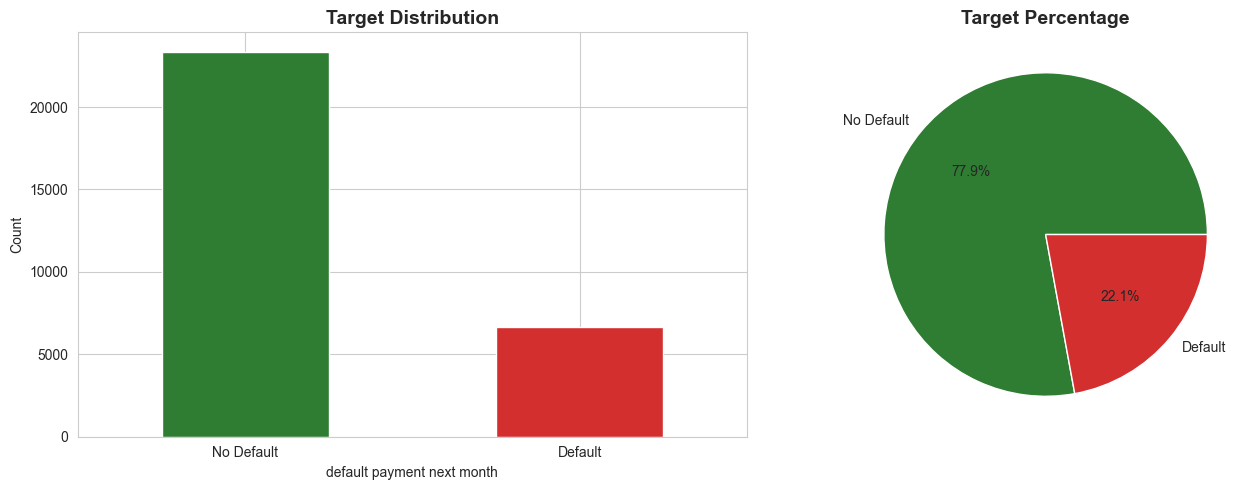

class imbalance: 77.9% vs 22.1% - will handle with SMOTE or class_weight=balanced


In [12]:
print('Target distribution:')
print(df[target].value_counts())
print()
print('Percentage:')
print(df[target].value_counts(normalize=True).round(3) * 100)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df[target].value_counts().plot(kind='bar', ax=axes[0], color=['#2E7D32', '#D32F2F'])
axes[0].set_title('Target Distribution', fontsize=14, fontweight='bold')
axes[0].set_xticklabels(['No Default', 'Default'], rotation=0)
axes[0].set_ylabel('Count')

df[target].value_counts().plot(kind='pie', ax=axes[1], autopct='%1.1f%%',
    colors=['#2E7D32', '#D32F2F'], labels=['No Default', 'Default'])
axes[1].set_title('Target Percentage', fontsize=14, fontweight='bold')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()
print('class imbalance: 77.9% vs 22.1% - will handle with SMOTE or class_weight=balanced')

## 3b. Univariate Distribution - Numerical Features

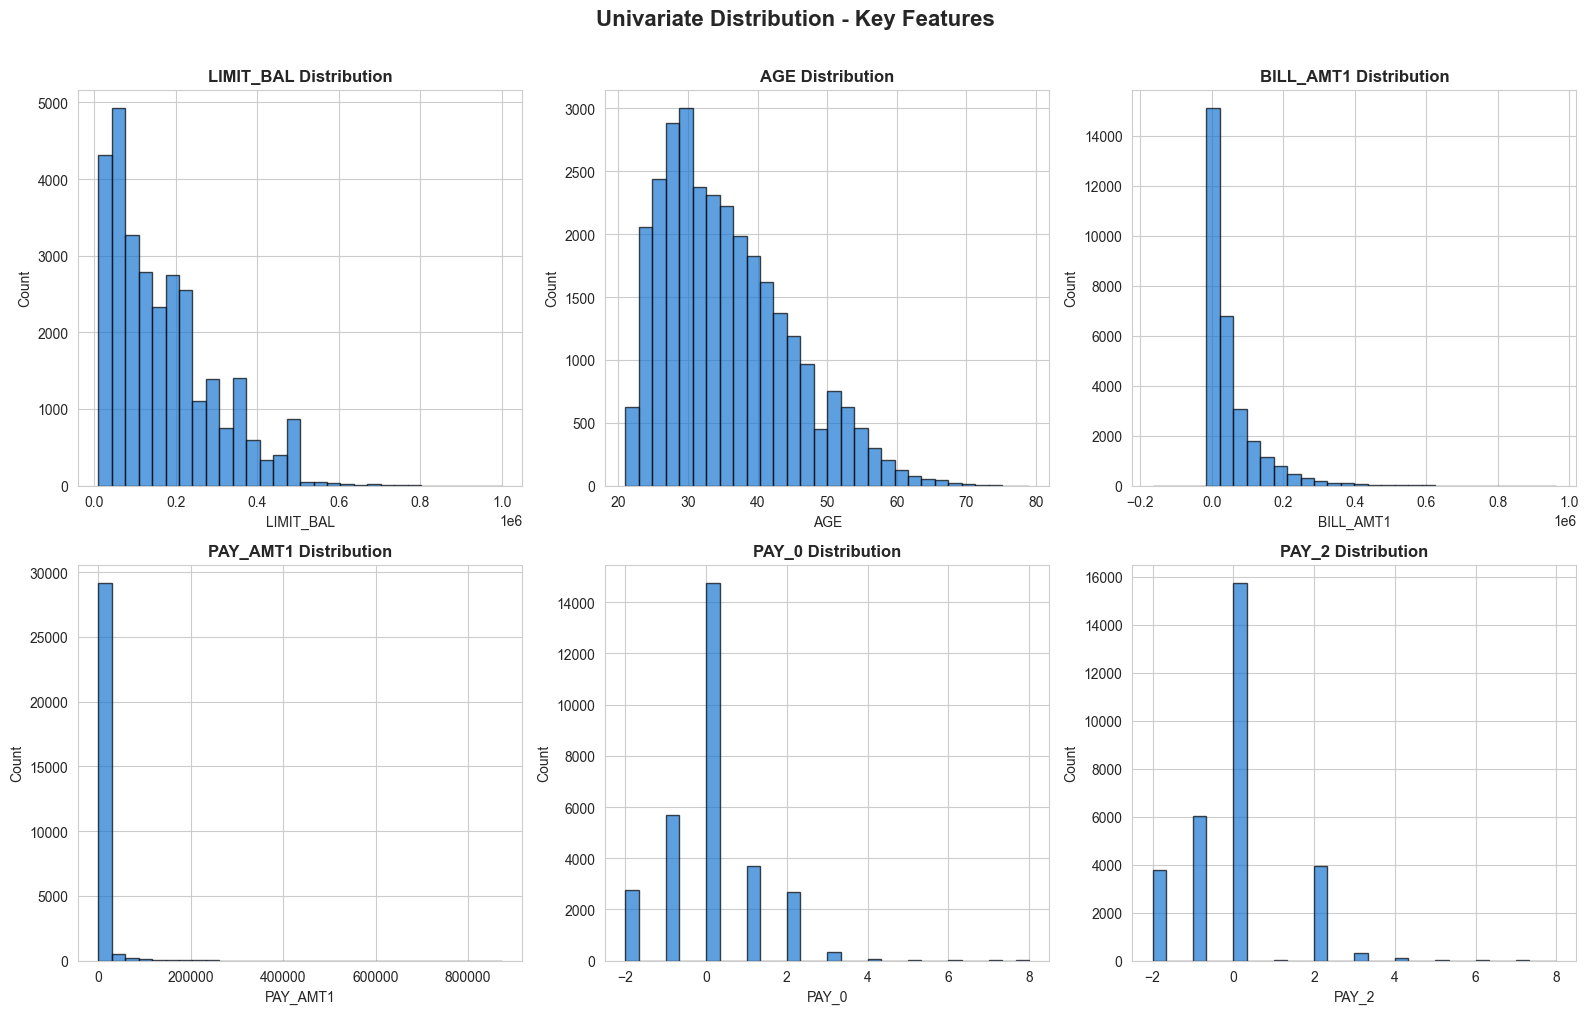

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

plot_cols = ['LIMIT_BAL', 'AGE', 'BILL_AMT1', 'PAY_AMT1', 'PAY_0', 'PAY_2']

for i, col in enumerate(plot_cols):
    axes[i].hist(df[col], bins=30, color='#1976D2', edgecolor='black', alpha=0.7)
    axes[i].set_title(f'{col} Distribution', fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')

plt.suptitle('Univariate Distribution - Key Features', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 3c. Univariate Distribution - Categorical Features

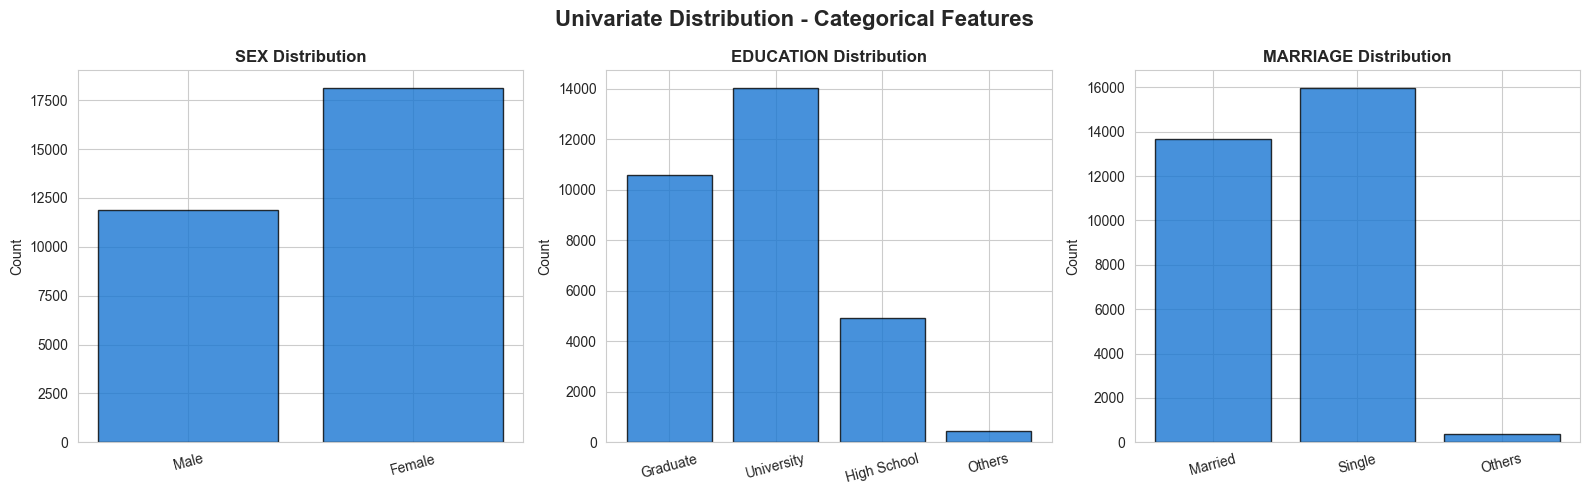

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

labels = {
    'SEX': {1: 'Male', 2: 'Female'},
    'EDUCATION': {1: 'Graduate', 2: 'University', 3: 'High School', 4: 'Others'},
    'MARRIAGE': {1: 'Married', 2: 'Single', 3: 'Others'}
}

for i, col in enumerate(cat_cols):
    counts = df[col].value_counts().sort_index()
    tick_labels = [labels[col].get(k, str(k)) for k in counts.index]
    axes[i].bar(tick_labels, counts.values, color='#1976D2', edgecolor='black', alpha=0.8)
    axes[i].set_title(f'{col} Distribution', fontweight='bold')
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x', rotation=15)

plt.suptitle('Univariate Distribution - Categorical Features', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# 4. CORRELATION + TRENDS

## 4a. Pearson Correlation - Numerical Features vs Target

Pearson correlation with target:
PAY_0        0.325
PAY_2        0.264
PAY_3        0.235
PAY_4        0.217
PAY_5        0.204
PAY_6        0.187
AGE          0.014
BILL_AMT6   -0.005
BILL_AMT5   -0.007
BILL_AMT4   -0.010
BILL_AMT3   -0.014
BILL_AMT2   -0.014
BILL_AMT1   -0.020
PAY_AMT6    -0.053
PAY_AMT5    -0.055
PAY_AMT3    -0.056
PAY_AMT4    -0.057
PAY_AMT2    -0.059
PAY_AMT1    -0.073
LIMIT_BAL   -0.154


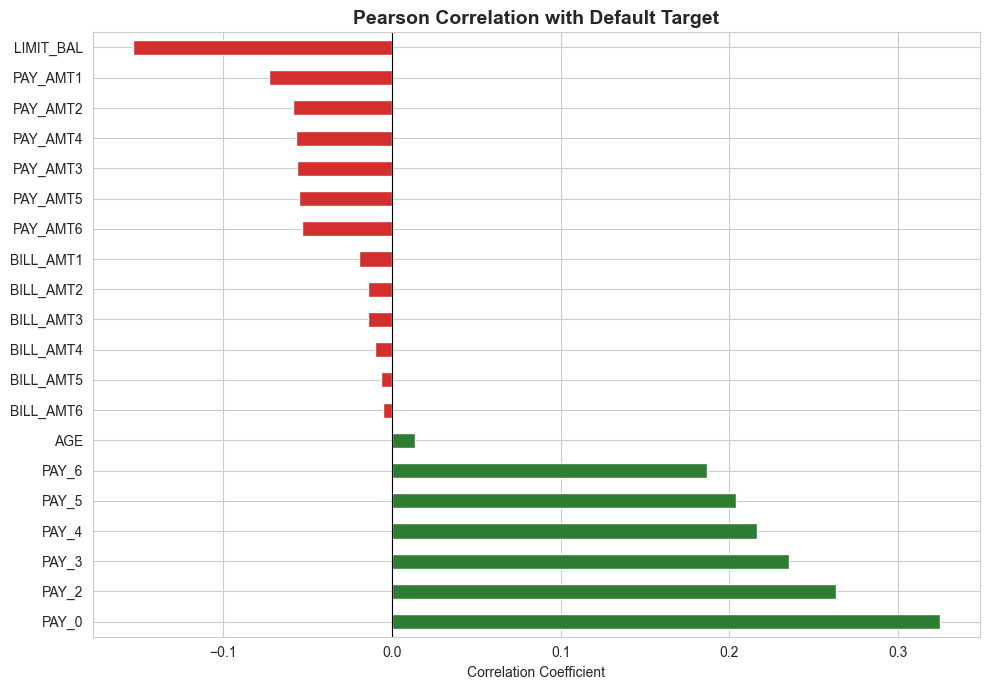

PAY_0 is the strongest predictor (r=0.325) - recent payment delay is the biggest risk signal


In [15]:
corr = df[num_cols + pay_cols].corrwith(df[target]).sort_values(ascending=False)

print('Pearson correlation with target:')
print(corr.round(3).to_string())

plt.figure(figsize=(10, 7))
colors = ['#2E7D32' if v > 0 else '#D32F2F' for v in corr]
corr.plot(kind='barh', color=colors)
plt.title('Pearson Correlation with Default Target', fontsize=14, fontweight='bold')
plt.xlabel('Correlation Coefficient')
plt.axvline(x=0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()
print('PAY_0 is the strongest predictor (r=0.325) - recent payment delay is the biggest risk signal')

## 4b. Correlation Heatmap - Full Feature Matrix

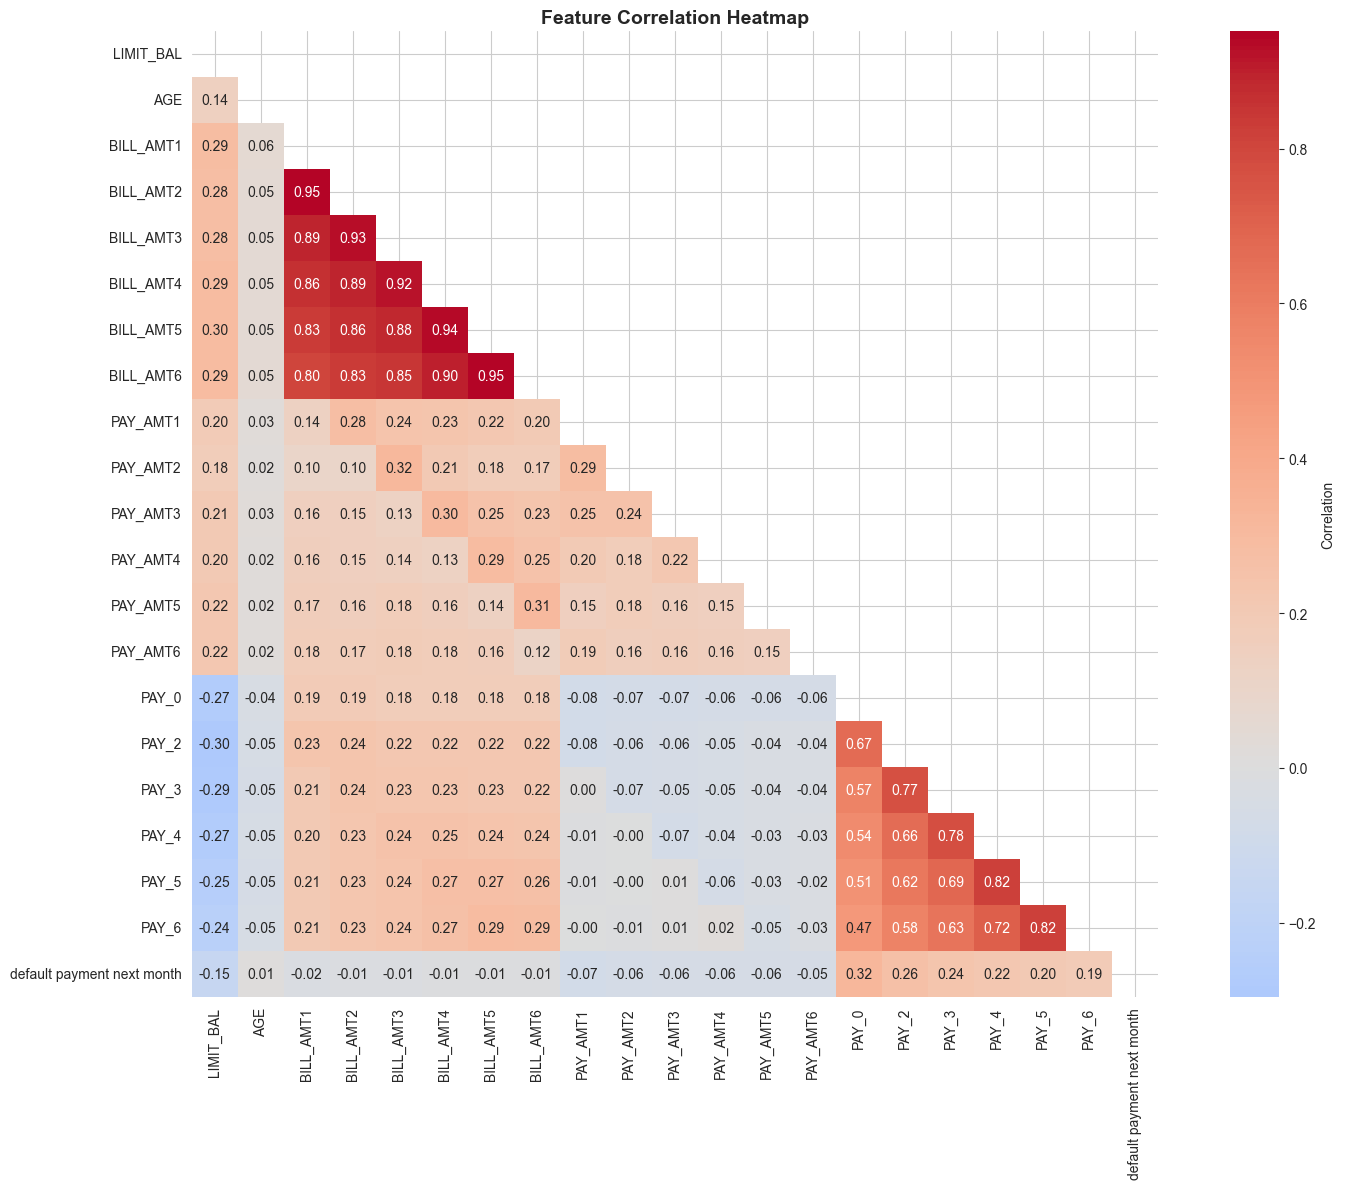

In [16]:
plt.figure(figsize=(16, 12))
corr_matrix = df[num_cols + pay_cols + [target]].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, cbar_kws={'label': 'Correlation'})
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 4c. Chi-Square Test - Categorical Features vs Target

In [17]:
print('Chi-Square Test Results (categorical features vs target):')
for col in cat_cols:
    ct = pd.crosstab(df[col], df[target])
    chi2, p, dof, _ = stats.chi2_contingency(ct)
    sig = 'SIGNIFICANT' if p < 0.05 else 'not significant'
    print(f'{col:12s}: chi2={chi2:8.2f}, p={p:.4f} -> {sig}')
print()
print('all 3 categorical features are statistically significant predictors of default')

Chi-Square Test Results (categorical features vs target):
SEX         : chi2=   47.71, p=0.0000 -> SIGNIFICANT
EDUCATION   : chi2=  160.41, p=0.0000 -> SIGNIFICANT
MARRIAGE    : chi2=   28.13, p=0.0000 -> SIGNIFICANT

all 3 categorical features are statistically significant predictors of default


## 4d. ANOVA - Numerical Features vs Target

In [18]:
print('ANOVA Test Results (numerical features vs target):')
for col in num_cols:
    g0 = df[df[target]==0][col]
    g1 = df[df[target]==1][col]
    f, p = stats.f_oneway(g0, g1)
    sig = 'SIGNIFICANT' if p < 0.05 else 'not significant'
    print(f'{col:12s}: F={f:8.2f}, p={p:.4f} -> {sig}')
print()
print('LIMIT_BAL has the highest F-score (724) - credit limit is a strong differentiator between defaulters and non-defaulters')

ANOVA Test Results (numerical features vs target):
LIMIT_BAL   : F=  724.07, p=0.0000 -> SIGNIFICANT
AGE         : F=    5.79, p=0.0161 -> SIGNIFICANT
BILL_AMT1   : F=   11.58, p=0.0007 -> SIGNIFICANT
BILL_AMT2   : F=    6.04, p=0.0140 -> SIGNIFICANT
BILL_AMT3   : F=    5.94, p=0.0148 -> SIGNIFICANT
BILL_AMT4   : F=    3.09, p=0.0786 -> not significant
BILL_AMT5   : F=    1.37, p=0.2416 -> not significant
BILL_AMT6   : F=    0.87, p=0.3521 -> not significant
PAY_AMT1    : F=  160.40, p=0.0000 -> SIGNIFICANT
PAY_AMT2    : F=  103.29, p=0.0000 -> SIGNIFICANT
PAY_AMT3    : F=   95.22, p=0.0000 -> SIGNIFICANT
PAY_AMT4    : F=   97.19, p=0.0000 -> SIGNIFICANT
PAY_AMT5    : F=   91.43, p=0.0000 -> SIGNIFICANT
PAY_AMT6    : F=   85.09, p=0.0000 -> SIGNIFICANT

LIMIT_BAL has the highest F-score (724) - credit limit is a strong differentiator between defaulters and non-defaulters


## 4e. Bivariate Analysis - Key Features vs Default

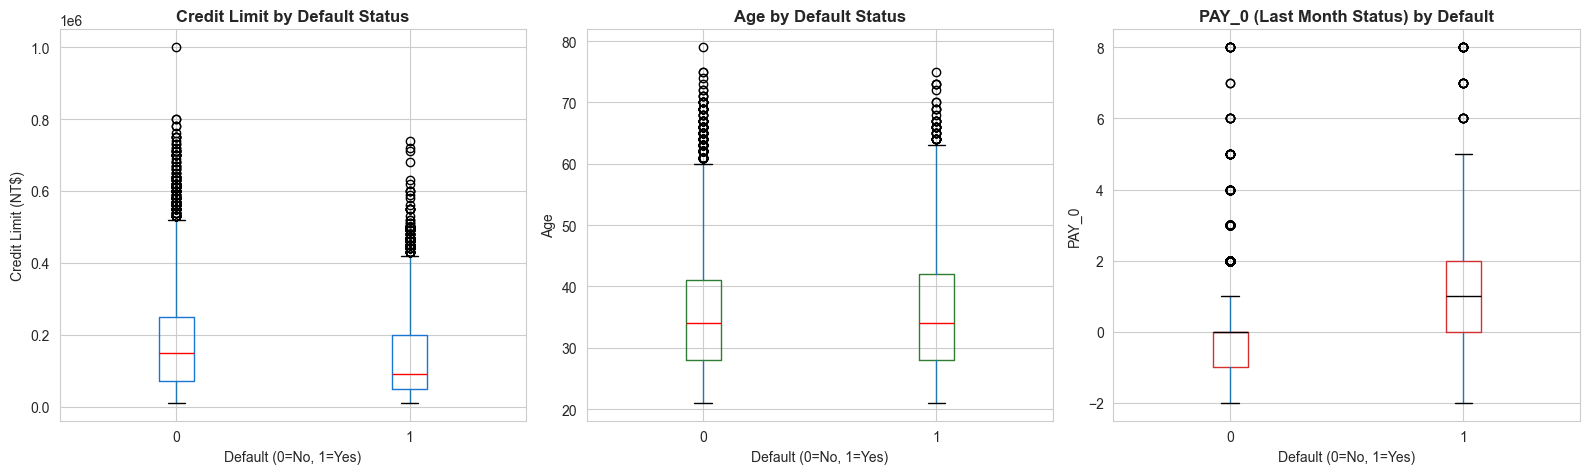

defaulters tend to have lower credit limits and higher recent payment delays


In [19]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

df.boxplot(column='LIMIT_BAL', by=target, ax=axes[0], 
           boxprops=dict(color='#1976D2'), medianprops=dict(color='red'))
axes[0].set_title('Credit Limit by Default Status', fontweight='bold')
axes[0].set_xlabel('Default (0=No, 1=Yes)')
axes[0].set_ylabel('Credit Limit (NT$)')


df.boxplot(column='AGE', by=target, ax=axes[1],
           boxprops=dict(color='#2E7D32'), medianprops=dict(color='red'))
axes[1].set_title('Age by Default Status', fontweight='bold')
axes[1].set_xlabel('Default (0=No, 1=Yes)')
axes[1].set_ylabel('Age')


df.boxplot(column='PAY_0', by=target, ax=axes[2],
           boxprops=dict(color='#D32F2F'), medianprops=dict(color='black'))
axes[2].set_title('PAY_0 (Last Month Status) by Default', fontweight='bold')
axes[2].set_xlabel('Default (0=No, 1=Yes)')
axes[2].set_ylabel('PAY_0')

plt.suptitle('')
plt.tight_layout()
plt.show()
print('defaulters tend to have lower credit limits and higher recent payment delays')

## 4f. Multivariate Analysis - Default Rate by Education & Marriage

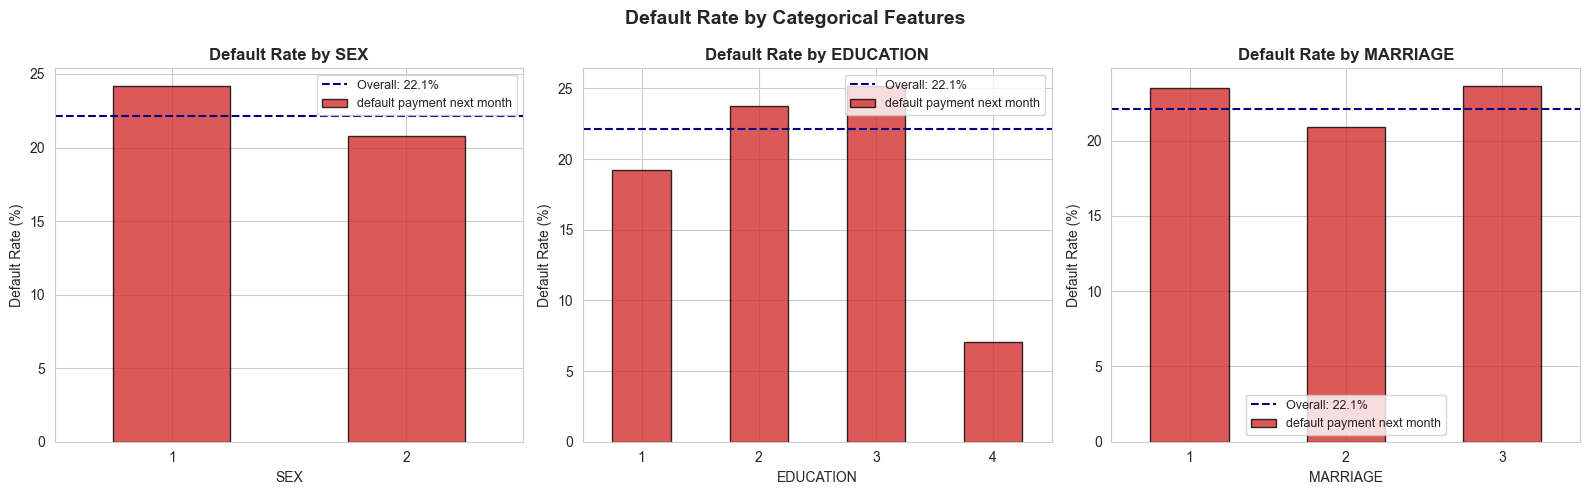

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, col in enumerate(cat_cols):
    default_rate = df.groupby(col)[target].mean() * 100
    default_rate.plot(kind='bar', ax=axes[i], color='#D32F2F', edgecolor='black', alpha=0.8)
    axes[i].set_title(f'Default Rate by {col}', fontweight='bold')
    axes[i].set_ylabel('Default Rate (%)')
    axes[i].set_xlabel(col)
    axes[i].tick_params(axis='x', rotation=0)
    axes[i].axhline(y=df[target].mean()*100, color='navy', linestyle='--', 
                    linewidth=1.5, label=f'Overall: {df[target].mean()*100:.1f}%')
    axes[i].legend(fontsize=9)

plt.suptitle('Default Rate by Categorical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# 5. OUTLIER ANALYSIS

In [21]:
outlier_summary = []
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n = ((df[col] < lower) | (df[col] > upper)).sum()
    if n > 0:
        outlier_summary.append({'Column': col, 'Count': n, 'Pct': f'{n/len(df)*100:.1f}%',
                                'Plan': 'Cap with IQR (Winsorize)'})

print(pd.DataFrame(outlier_summary).to_string())
print()
print('Plan: apply Winsorization (cap at 1st and 99th percentile) during preprocessing')

       Column  Count    Pct                      Plan
0   LIMIT_BAL    167   0.6%  Cap with IQR (Winsorize)
1         AGE    272   0.9%  Cap with IQR (Winsorize)
2   BILL_AMT1   2400   8.0%  Cap with IQR (Winsorize)
3   BILL_AMT2   2395   8.0%  Cap with IQR (Winsorize)
4   BILL_AMT3   2469   8.2%  Cap with IQR (Winsorize)
5   BILL_AMT4   2622   8.7%  Cap with IQR (Winsorize)
6   BILL_AMT5   2725   9.1%  Cap with IQR (Winsorize)
7   BILL_AMT6   2693   9.0%  Cap with IQR (Winsorize)
8    PAY_AMT1   2745   9.2%  Cap with IQR (Winsorize)
9    PAY_AMT2   2714   9.0%  Cap with IQR (Winsorize)
10   PAY_AMT3   2598   8.7%  Cap with IQR (Winsorize)
11   PAY_AMT4   2994  10.0%  Cap with IQR (Winsorize)
12   PAY_AMT5   2945   9.8%  Cap with IQR (Winsorize)
13   PAY_AMT6   2958   9.9%  Cap with IQR (Winsorize)

Plan: apply Winsorization (cap at 1st and 99th percentile) during preprocessing


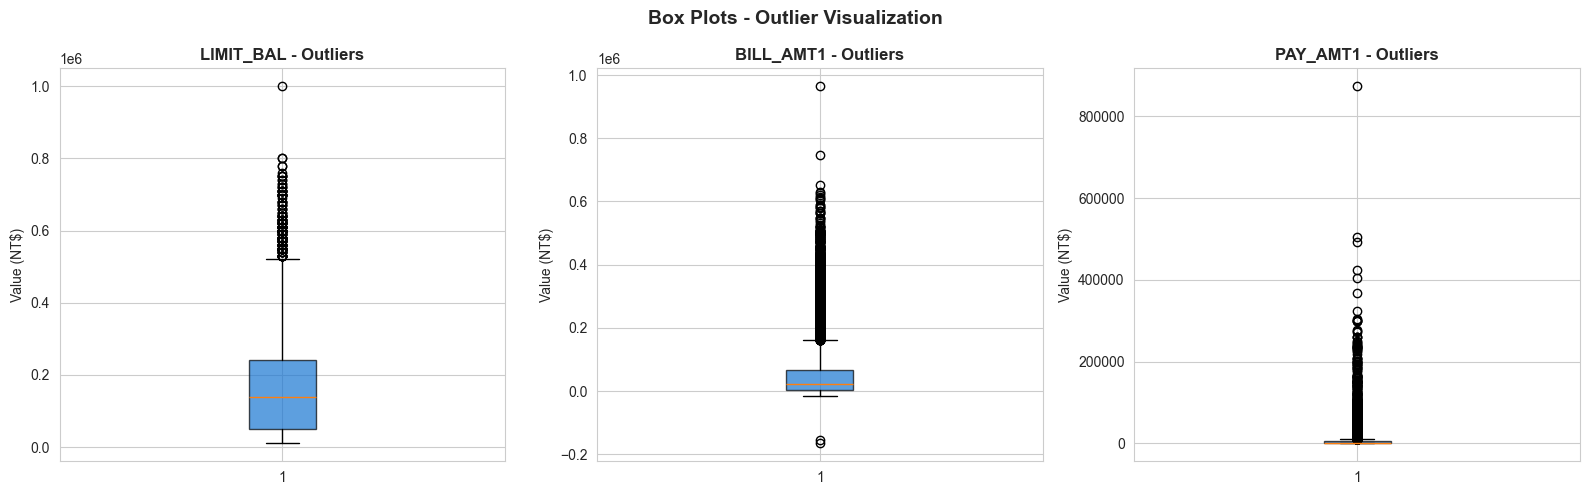

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for i, col in enumerate(['LIMIT_BAL', 'BILL_AMT1', 'PAY_AMT1']):
    axes[i].boxplot(df[col], vert=True, patch_artist=True,
                    boxprops=dict(facecolor='#1976D2', alpha=0.7))
    axes[i].set_title(f'{col} - Outliers', fontweight='bold')
    axes[i].set_ylabel('Value (NT$)')
plt.suptitle('Box Plots - Outlier Visualization', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# 6. PLANNING: PREPROCESSING

### Preprocessing Steps

1. **Drop ID column** — not predictive, already done
2. **Fix categorical encoding** — remap EDUCATION (0,5,6 → 4) and MARRIAGE (0 → 3), already done
3. **Handle outliers** — Winsorize bill amounts and payment amounts at 1st/99th percentile
4. **Handle class imbalance** — use `class_weight='balanced'` in models OR apply SMOTE on training set only
5. **Feature scaling** — StandardScaler on numerical features (LIMIT_BAL, AGE, BILL_AMTs, PAY_AMTs)
6. **Encode categoricals** — SEX, EDUCATION, MARRIAGE are already integers; treat as ordinal or one-hot encode
7. **Train/Test split** — 80/20 stratified split to preserve class ratio
8. **Drop multicollinear features** — BILL_AMT1-6 are highly correlated with each other; may drop some or use PCA

In [23]:
from scipy.stats.mstats import winsorize
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

df_clean = df.copy()

for col in bill_cols + pay_amt_cols:
    df_clean[col] = winsorize(df_clean[col], limits=[0.01, 0.01])


X = df_clean.drop(columns=[target])
y = df_clean[target]


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, 
                                                      random_state=42, stratify=y)


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f'Train set: {X_train.shape} | Test set: {X_test.shape}')
print(f'Train target distribution: {y_train.value_counts(normalize=True).round(3).to_dict()}')
print(f'Test target distribution:  {y_test.value_counts(normalize=True).round(3).to_dict()}')
print('stratified split preserved class ratio')

Train set: (24000, 23) | Test set: (6000, 23)
Train target distribution: {0: 0.779, 1: 0.221}
Test target distribution:  {0: 0.779, 1: 0.221}
stratified split preserved class ratio


# 7. PLANNING: MODELING APPROACH

### Models to Try

| Model | Why |
|-------|-----|
| Logistic Regression | Baseline, interpretable, works well with scaled features |
| Decision Tree | Interpretable, handles non-linear patterns |
| Random Forest | Ensemble, robust to outliers, handles class imbalance with class_weight |
| XGBoost | Often best performance on tabular imbalanced data |

### Evaluation Metrics

Accuracy alone is misleading here because of class imbalance (77/22 split). We care more about catching defaulters:

| Metric | Why |
|--------|-----|
| **Recall (Sensitivity)** | Most important — catching actual defaulters (minimize false negatives) |
| **Precision** | Avoiding false alarms on good clients |
| **F1-Score** | Balance between precision and recall |
| **ROC-AUC** | Overall model discrimination ability |
| **Confusion Matrix** | Full breakdown of TP, TN, FP, FN |

In [24]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

models = {
    'Logistic Regression': LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(class_weight='balanced', max_depth=5, random_state=42),
    'Random Forest': RandomForestClassifier(class_weight='balanced', n_estimators=100, random_state=42)
}

results = []
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]
    
    from sklearn.metrics import recall_score, precision_score, f1_score, accuracy_score
    results.append({
        'Model': name,
        'Accuracy': round(accuracy_score(y_test, y_pred), 3),
        'Precision': round(precision_score(y_test, y_pred), 3),
        'Recall': round(recall_score(y_test, y_pred), 3),
        'F1': round(f1_score(y_test, y_pred), 3),
        'ROC-AUC': round(roc_auc_score(y_test, y_prob), 3)
    })

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

              Model  Accuracy  Precision  Recall    F1  ROC-AUC
Logistic Regression     0.675      0.365   0.636 0.464    0.714
      Decision Tree     0.771      0.484   0.552 0.516    0.757
      Random Forest     0.811      0.639   0.337 0.441    0.755


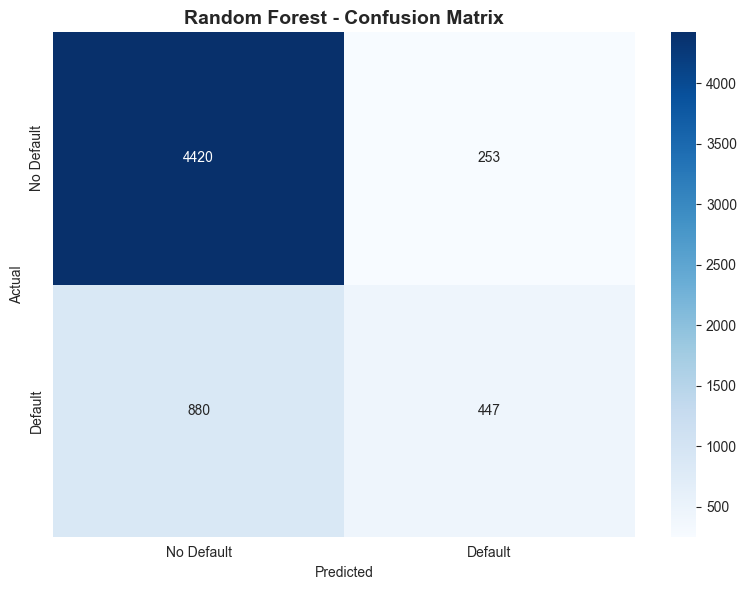

              precision    recall  f1-score   support

  No Default       0.83      0.95      0.89      4673
     Default       0.64      0.34      0.44      1327

    accuracy                           0.81      6000
   macro avg       0.74      0.64      0.66      6000
weighted avg       0.79      0.81      0.79      6000



In [25]:
best_model = models['Random Forest']
y_pred_rf = best_model.predict(X_test_scaled)

cm = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Default', 'Default'],
            yticklabels=['No Default', 'Default'])
plt.title('Random Forest - Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

print(classification_report(y_test, y_pred_rf, target_names=['No Default', 'Default']))

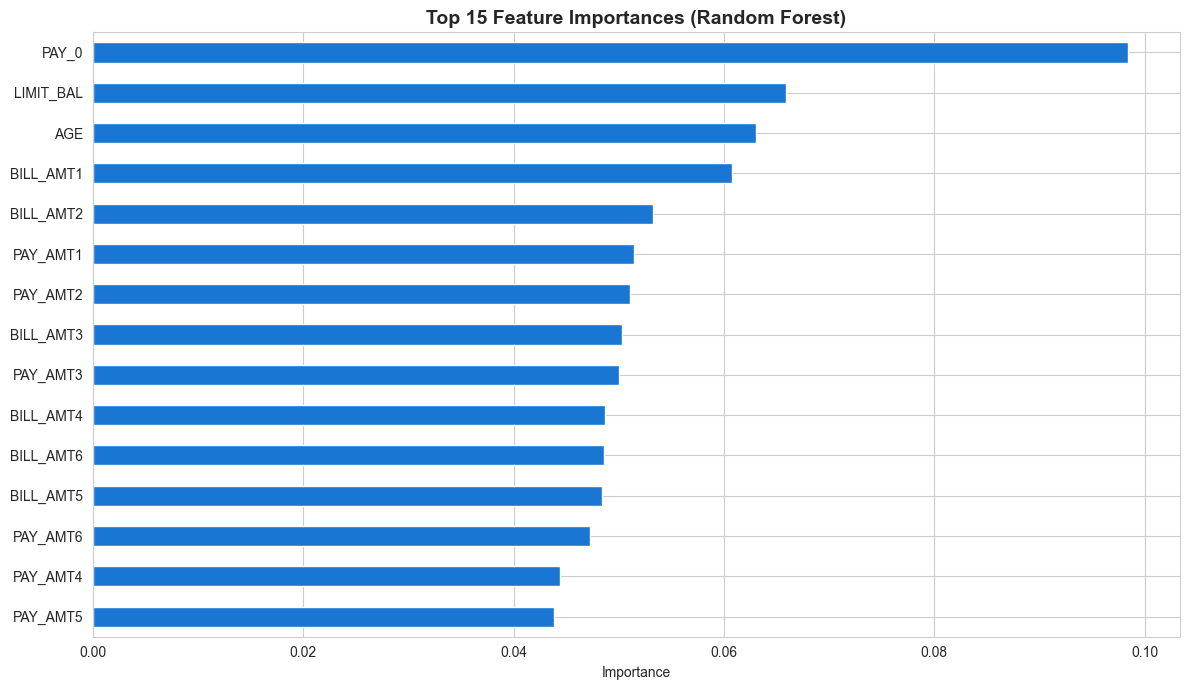

Top 5 most important features:
PAY_0        0.0984
LIMIT_BAL    0.0659
AGE          0.0630
BILL_AMT1    0.0607
BILL_AMT2    0.0533


In [26]:
feature_imp = pd.Series(best_model.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(12, 7))
feature_imp.head(15).plot(kind='barh', color='#1976D2')
plt.title('Top 15 Feature Importances (Random Forest)', fontsize=14, fontweight='bold')
plt.xlabel('Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print('Top 5 most important features:')
print(feature_imp.head(5).round(4).to_string())